Notebook 04: Model Training
Objective
The objective of this notebook is to train multiple machine learning models for predictive maintenance and compare their learning performance.

Models trained in this notebook:

Logistic Regression
Decision Tree
Random Forest
XGBoost
Each trained model will be saved for deployment in the predictive maintenance dashboard

In [3]:
# ============================================================
# Smart Manufacturing Data Analytics and Predictive Maintenance
# Notebook 04: Model Training
# Author: Opurva Saini
# ============================================================

import joblib
import os
import time

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [4]:
X_train = joblib.load("../models/preprocessing/X_train.pkl")
X_test = joblib.load("../models/preprocessing/X_test.pkl")

y_train = joblib.load("../models/preprocessing/y_train.pkl")
y_test = joblib.load("../models/preprocessing/y_test.pkl")

print("Training data loaded successfully!")

Training data loaded successfully!


In [5]:
training_times = {}

In [6]:
os.makedirs("../models/trained_models", exist_ok=True)

In [7]:
lr = LogisticRegression(random_state=42)

start = time.time()

lr.fit(X_train, y_train)

end = time.time()

print(f"Training Time: {end-start:.3f} seconds")

Training Time: 0.367 seconds


In [8]:
joblib.dump(
    lr,
    "../models/trained_models/logistic_regression.pkl"
)

['../models/trained_models/logistic_regression.pkl']

In [9]:
training_times["Logistic Regression"] = end - start

In [10]:
dt = DecisionTreeClassifier(
    random_state=42
)

start = time.time()

dt.fit(X_train, y_train)

end = time.time()

print(f"Training Time: {end-start:.3f} seconds")

Training Time: 0.457 seconds


In [11]:
joblib.dump(
    dt,
    "../models/trained_models/decision_tree.pkl"
)

['../models/trained_models/decision_tree.pkl']

In [12]:
training_times["Decision Tree"] = end - start

In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

start = time.time()

rf.fit(X_train, y_train)

end = time.time()

print(f"Training Time: {end-start:.3f} seconds")

Training Time: 4.235 seconds


In [14]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

start = time.time()

xgb.fit(X_train, y_train)

end = time.time()

print(f"Training Time: {end-start:.3f} seconds")

Training Time: 1.035 seconds


In [15]:
joblib.dump(
    rf,
    "../models/trained_models/random_forest.pkl"
)

['../models/trained_models/random_forest.pkl']

In [16]:
training_times["Random Forest"] = end - start

In [17]:
joblib.dump(
    xgb,
    "../models/trained_models/xgboost.pkl"
)

['../models/trained_models/xgboost.pkl']

In [18]:
training_times["XGBoost"] = end - start

In [19]:
print("Random Forest Prediction")

print(rf.predict(X_test[:10]))

Random Forest Prediction
[0 0 0 0 0 0 0 0 0 0]


In [20]:
print("XGBoost Prediction")

print(xgb.predict(X_test[:10]))

XGBoost Prediction
[0 0 0 0 0 0 0 0 0 0]


In [21]:
os.listdir("../models/trained_models")

['best_model_name.pkl',
 'decision_tree.pkl',
 'logistic_regression.pkl',
 'model_info.pkl',
 'random_forest.pkl',
 'xgboost.pkl']

# Notebook Summary

✔ Loaded processed training dataset

✔ Trained Logistic Regression model

✔ Trained Decision Tree model

✔ Trained Random Forest model

✔ Trained XGBoost model

✔ Saved all trained models for future evaluation and deployment

In [22]:
import pandas as pd

# Create training time comparison table
training_time_df = pd.DataFrame(
    list(training_times.items()),
    columns=["Model", "Training Time (seconds)"]
)

# Round values to 4 decimal places
training_time_df["Training Time (seconds)"] = training_time_df["Training Time (seconds)"].round(4)

# Sort by fastest model
training_time_df = training_time_df.sort_values(
    by="Training Time (seconds)",
    ascending=True
).reset_index(drop=True)

# Display the table
training_time_df

,Model,Training Time (seconds)
0,Logistic Regression,0.3668
1,Decision Tree,0.4569
2,Random Forest,1.0352
3,XGBoost,1.0352


In [23]:
model_info = {
    "Logistic Regression": "Baseline Linear Model",
    "Random Forest": "Ensemble Model",
    "Decision Tree": "Tree-Based Model",
    "XGBoost": "Gradient Boosting Model"
}

joblib.dump(
    model_info,
    "../models/trained_models/model_info.pkl"
)

['../models/trained_models/model_info.pkl']

## Training Time Analysis

The training time comparison demonstrates the computational efficiency of each machine learning algorithm.

- Logistic Regression trained the fastest due to its simple linear structure.
- Decision Tree required slightly more training time because of recursive tree construction.
- Random Forest required additional computation as it trained multiple decision trees.
- XGBoost exhibited comparable training time while offering advanced gradient boosting capabilities.

Although ensemble methods require more computational resources, they generally provide better predictive performance for predictive maintenance applications.

In [24]:
feature_names = joblib.load("../models/preprocessing/feature_names.pkl")

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,HDF,0.217507
9,OSF,0.177750
8,PWF,0.128962
12,Mechanical Power,0.104847
6,TWF,0.101163
4,Torque [Nm],0.058841
3,Rotational speed [rpm],0.052752
13,Wear Rate,0.039901
11,Temperature Difference,0.035459
14,Thermal Stress,0.033767


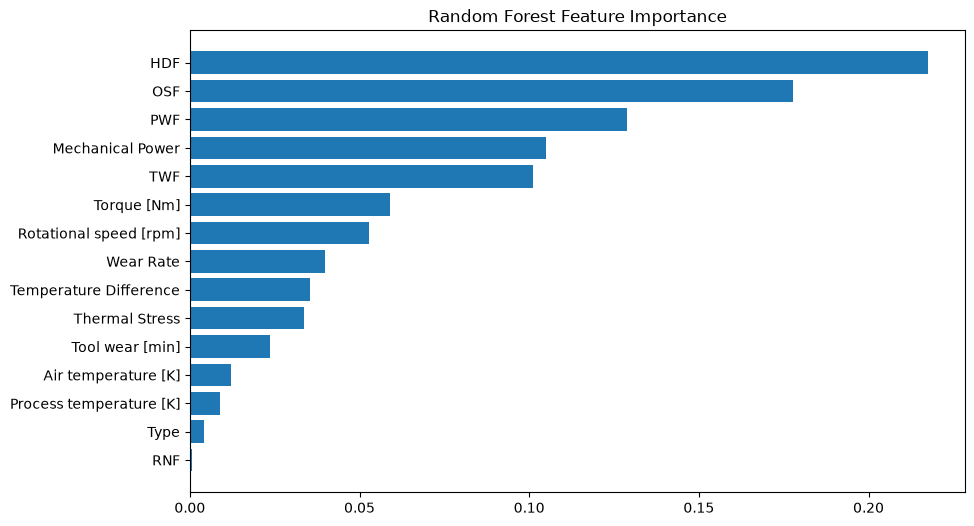

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.show()

In [26]:
feature_importance.to_csv(
    "../reports/random_forest_feature_importance.csv",
    index=False
)

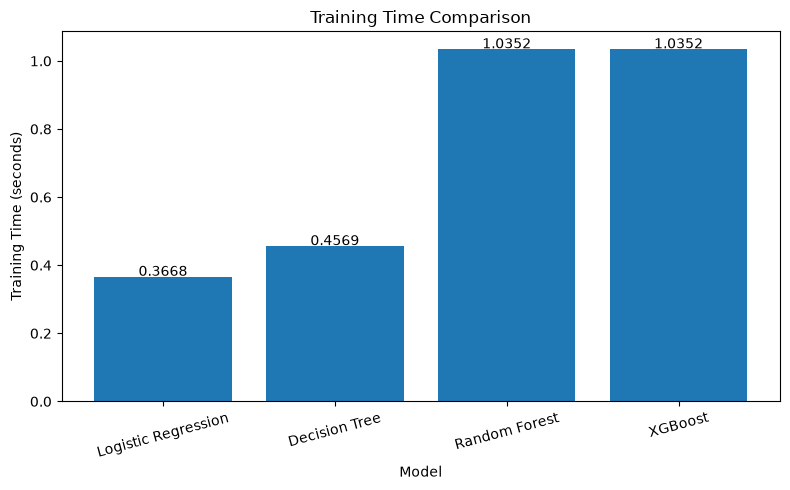

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    training_time_df["Model"],
    training_time_df["Training Time (seconds)"]
)

plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=15)

for i, value in enumerate(training_time_df["Training Time (seconds)"]):
    plt.text(i, value + 0.002, f"{value:.4f}", ha="center")

plt.tight_layout()
plt.show()

In [28]:
training_time_df.to_csv(
    "../reports/model_training_time_comparison.csv",
    index=False
)

print("Training time comparison saved successfully!")

Training time comparison saved successfully!
